# Endelig modellsammenligning: out-of-sample 2024

Tre prismodeller for ren egen-skadepremie (forventet skadekostnad per eksponeringsår)
sammenlignes på ett ubrukt år: **Tweedie-GLM**, **toleddet GLM** (frekvens × severity)
og **CatBoost**. Modellene er spesifisert og refittet på 2022–2023 i egne notebooks
(`02_frekvens`, `03_severity`, `04_tweedie`, `05_catboost`) og lagret i
`models/`. Ingen modell trenes eller justeres her.

2024 er ikke brukt til modellvalg, seleksjon eller tuning. Testlåsen er aktiv:
ingen 2024-data leses før `RUN_2024_EVALUATION` og godkjenningskoden bevisst settes.

In [1]:
from IPython.display import display

from src_core_glm.model_data import build_development_frames
from src_model_comparison.locked_models import load_locked_model
from src_model_comparison.test_evaluation import (
    build_approved_test_frame,
    build_calibration_table,
    evaluate_pricing_models,
    plot_test_comparison,
)

TWEEDIE_POWER = 1.744  # samme avrundede p som i CatBoost og protokollen under
RUN_2024_EVALUATION = True  # godkjent av prosjekteier etter at alle modeller er låst
APPROVAL_CODE = "APPROVED_2024_TEST_EVALUATION"

## 1. Modellene

Alle tre estimerer $\mu_i=E[S_i/e_i]$, forventet skadekostnad per eksponeringsår for
poliseår $i$ med totalkostnad $S_i$ og eksponering $e_i$. Prediktorene er de samme 12
kandidatvariablene i alle modellene; hver modell velger selv hvilke som brukes.

**Tweedie-GLM.** Ren premie modelleres direkte, med log-link og vekt $e_i$:

$$
\frac{S_i}{e_i}\sim\operatorname{Tweedie}\!\left(\mu_i,\tfrac{\phi}{e_i},p\right),
\qquad
\log\mu_i=\beta_0+\gamma^{\mathrm{type}}_i+\gamma^{\mathrm{year}}_i+\gamma^{\mathrm{area}}_i
+\gamma^{\mathrm{pay}}_i+\gamma^{\mathrm{fuel}}_i+\gamma^{\mathrm{seat}}_i+\gamma^{\mathrm{bus}}_i
+\beta_v\log V_i+f_3(\mathrm{age}_i).
$$

**Toleddet GLM.** Frekvens og severity modelleres hver for seg, og premien er produktet:

$$
\widehat R_i=\widehat\lambda_i\,\widehat s_i,
\qquad
\log\lambda_i=\beta_0+\gamma^{\mathrm{type}}_i+\gamma^{\mathrm{year}}_i+\gamma^{\mathrm{area}}_i
+\gamma^{\mathrm{pay}}_i+\gamma^{\mathrm{bus}}_i+\beta_v\log V_i+f_4(\mathrm{age}_i),
$$

$$
\log s_i=\alpha_0+\delta^{\mathrm{type}}_i+\delta^{\mathrm{year}}_i+\delta^{\mathrm{area}}_i
+\delta^{\mathrm{bus}}_i+\alpha_v\log V_i+\alpha_a\,\mathrm{age}_i.
$$

Frekvensen er Poisson (vekt $e_i$), severity er Gamma på poliseår med skade (vekt
antall skader). $f_k$ er en naturlig kubisk spline med $k$ frihetsgrader.

**CatBoost.** Gradientboostede symmetriske trær med log-link og Tweedie-tap:

$$
\widehat\mu(x)=\exp\Big\{\sum_{m=1}^{M}\eta\,t_m(x)\Big\},
$$

med $M$ trær av dybde $d$, læringsrate $\eta$ og $L_2$-regularisering $\lambda$ valgt
ved gruppe-CV (verdiene står i `05_catboost`). Tweedie-GLM og CatBoost bruker
$p=1.744$. Den fullstendige spesifikasjonen (leddene, referansenivåene og antall
parametere) står i hver modellnotebook.

In [2]:
# Lås opp de lagrede modellene. Brand-poolingen læres kun fra 2022–2023.
retained_brands = build_development_frames()["retained_brands"]
frequency_model = load_locked_model("frequency")
severity_model = load_locked_model("severity")
tweedie_model = load_locked_model("tweedie")
catboost_model = load_locked_model("catboost")

prediction_functions = {
    "Tweedie-GLM": tweedie_model,
    "Toleddet GLM": lambda frame: frequency_model(frame) * severity_model(frame),
    "CatBoost": catboost_model,
}

## 2. Testprotokoll

Med observert $R_i=S_i/e_i$ og predikert $\widehat R_i$ måles hver modell med
eksponeringsvektet Tweedie-deviance ($p=1.744$), vektet MAE og porteføljebalanse
$\sum_i e_i\widehat R_i\big/\sum_i S_i-1$. **Primærmål er deviance; lavere er bedre.**
Kalibreringsplottet (ti like store prediksjonsgrupper) brukes som kontroll: en modell
med lavest deviance regnes bare som best hvis den ikke viser vesentlig systematisk skjevhet.

`year` er en låst kategorisk term og 2024 finnes ikke i treningsdata, så alle modeller skåres
med 2023-nivået. Numeriske prediktorer klippes til treningsområdet ved skåring.

In [3]:
if RUN_2024_EVALUATION:
    test_frame = build_approved_test_frame(retained_brands, approval_code=APPROVAL_CODE)
    results, predictions = evaluate_pricing_models(
        test_frame, prediction_functions, power=TWEEDIE_POWER
    )
    calibration = build_calibration_table(test_frame, predictions)

## 3. Resultater

In [4]:
if RUN_2024_EVALUATION:
    display(results.round(3))

,Modell,Tweedie-deviance,Vektet MAE,Observert incurred (EUR),Predikert incurred (EUR),Balanse (%)
1,Toleddet GLM,32.180,398.220,9689550.32,9780052.482,0.934
0,Tweedie-GLM,32.204,396.007,9689550.32,9609413.766,-0.827
2,CatBoost,32.213,391.357,9689550.32,9300755.513,-4.013


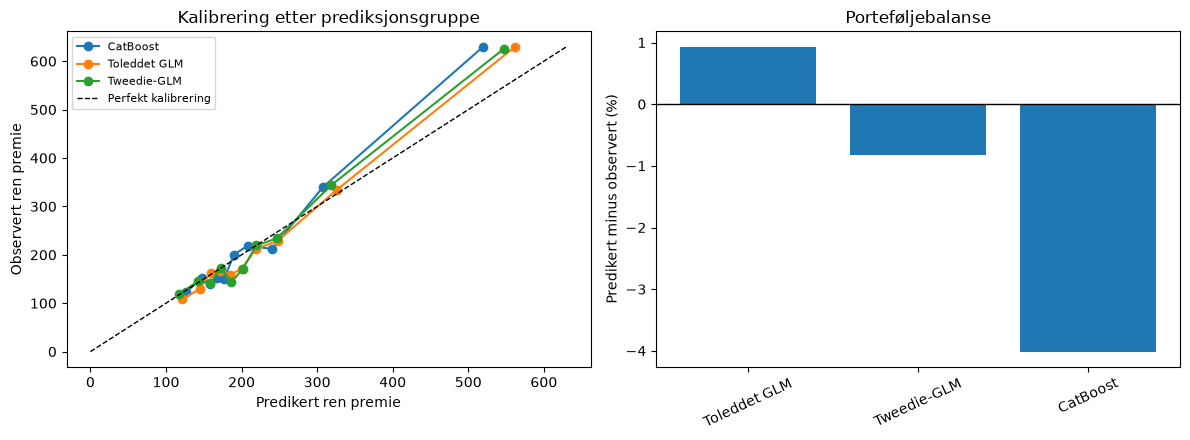

In [5]:
if RUN_2024_EVALUATION:
    figure = plot_test_comparison(results, calibration)

## 4. Begrensninger

- **Ett testår.** Rangeringen dokumenterer generalisering til 2024, ikke en universell
  eller kausal effekt. Forskjeller i deviance mellom modellene er ikke gitt usikkerhet;
  dersom modellene ligger tett, bør forskjellene ikke tolkes som sikre.
- **Årsdrift.** Alle modeller skåres med 2023-nivået. En prisendring eller endret
  skadenivå fra 2023 til 2024 blir derfor liggende i porteføljebalansen og er ikke en
  modellfeil.
- **Optimistiske utviklingsscorer.** Variabelutvalg, spesifikasjon og hyperparametere er
  valgt på samme fem CV-folder, og $p$ er estimert på hele utviklingssettet.
- **CatBoost er skjev i nivå.** Modellen undervurderer porteføljen allerede på
  utviklingsdata (−3,6 % balanse på 2023-radene i en tørrkjøring uten 2024). Log-linken og
  regulariseringen gir ikke full nivåkalibrering; balansen på teståret bør leses med det
  i minne.
- **Lav forklart varians.** Skadekostnad per poliseår har få og skjeve skader; alle
  modeller forklarer bare en liten andel av variasjonen (D² ≈ 0,02 for CatBoost).

## 5. Tolkning

Modellene er evaluert én gang på 2024, og ingenting er justert etter resultatet.

- **Deviance er praktisk talt lik.** Toleddet GLM 32,180, Tweedie-GLM 32,204 og
  CatBoost 32,213: forskjellen mellom best og dårligst er 0,033 (0,1 %). Uten et
  usikkerhetsmål og med ett testår kan ikke rangeringen tolkes som sikker.
  CatBoost har lavest vektet MAE (391,4 mot 396,0 og 398,2).
- **GLM-ene er bedre kalibrert i nivå.** Porteføljebalansen er +0,9 % (toleddet) og
  −0,8 % (Tweedie), mens CatBoost undervurderer med −4,0 %. Det ligner skjevheten
  på utviklingsdata (−3,6 % på 2023), så det er en systematisk nivåskjevhet i
  modellen og ikke bare årsdrift.
- **Alle modellene undervurderer de dyreste risikoene.** I øverste prediksjonsgruppe er
  observert ren premie ca. 630 mot ca. 520–560 predikert, og CatBoost ligger lavest.

**Konklusjon.** CatBoost gir ingen målbar gevinst over GLM-ene i deviance og er dårligere
kalibrert i nivå. Med lav forklart varians ($D^2\approx 0{,}02$ i utvikling) er dette
forenlig med at signalet i dataene i hovedsak fanges av de enkle GLM-ene. De er
dessuten enklere å forklare og revidere, så Tweedie-GLM eller den toleddede modellen
er det naturlige valget; CatBoost ville trengt rekalibrering av nivået først.
En parvis bootstrap over polisene på testpredikasjonene er neste steg for å kvantifisere
om de små devianceforskjellene er noe annet enn støy.